Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, chisquare

Vectorized Dice Setup

In [2]:
# number of parallel simulations
N = 10000  

# simulate 3 dice per player → shape (N, 3)
def roll_dice(n_samples):
    return np.random.randint(1, 7, size=(n_samples, 3))

Vectorized Round Simulation

In [3]:
def simulate_round(n_samples):
    p1 = roll_dice(n_samples)
    p2 = roll_dice(n_samples)

    p1_sum = np.sum(p1, axis=1)
    p2_sum = np.sum(p2, axis=1)

    # triple ones
    p1_triple = np.all(p1 == 1, axis=1)
    p2_triple = np.all(p2 == 1, axis=1)

    # initialize scores
    p1_score = np.zeros(n_samples)
    p2_score = np.zeros(n_samples)

    # rules (vectorized masks)
    p1_win = (p1_sum > p2_sum)
    p2_win = (p2_sum > p1_sum)
    draw = (p1_sum == p2_sum)

    # triple ones override
    p1_score[p1_win] = 1
    p2_score[p2_win] = 1

    p1_score[draw] = 0.5
    p2_score[draw] = 0.5

    p1_score[p1_triple] = 1
    p2_score[p1_triple] = 0

    p2_score[p2_triple] = 1
    p1_score[p2_triple] = 0

    return p1_score, p2_score, p1, p2

Game Simulation (minimal loop)

In [4]:
def simulate_games(n_games=1000):
    p1_total = np.zeros(n_games)
    p2_total = np.zeros(n_games)

    history_p1 = []
    history_p2 = []

    win_rolls = []
    lose_rolls = []

    finished = np.zeros(n_games, dtype=bool)

    while not np.all(finished):
        p1_round, p2_round, p1_rolls, p2_rolls = simulate_round(n_games)

        p1_total += p1_round
        p2_total += p2_round

        history_p1.append(p1_total.copy())
        history_p2.append(p2_total.copy())

        # collect rolls
        p1_wins = p1_round > p2_round
        p2_wins = p2_round > p1_round

        win_rolls.extend(p1_rolls[p1_wins].flatten())
        win_rolls.extend(p2_rolls[p2_wins].flatten())

        lose_rolls.extend(p2_rolls[p1_wins].flatten())
        lose_rolls.extend(p1_rolls[p2_wins].flatten())

        # stopping condition
        finished = ((p1_total >= 5) | (p2_total >= 5)) & (p1_total != p2_total)

    winners = (p1_total > p2_total).astype(int)

    return winners, history_p1, history_p2, win_rolls, lose_rolls

Histogram (Winner vs Loser)

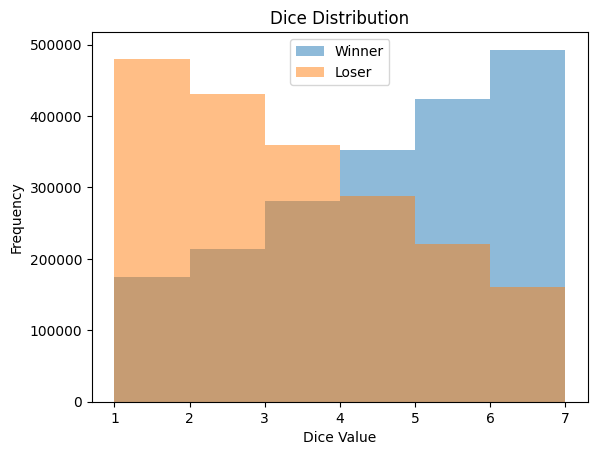

In [5]:
winners, h1, h2, win_rolls, lose_rolls = simulate_games(500)

plt.figure()
plt.hist(win_rolls, bins=np.arange(1, 8), alpha=0.5, label="Winner")
plt.hist(lose_rolls, bins=np.arange(1, 8), alpha=0.5, label="Loser")
plt.legend()
plt.xlabel("Dice Value")
plt.ylabel("Frequency")
plt.title("Dice Distribution")
plt.show()

Cumulative Score Plot

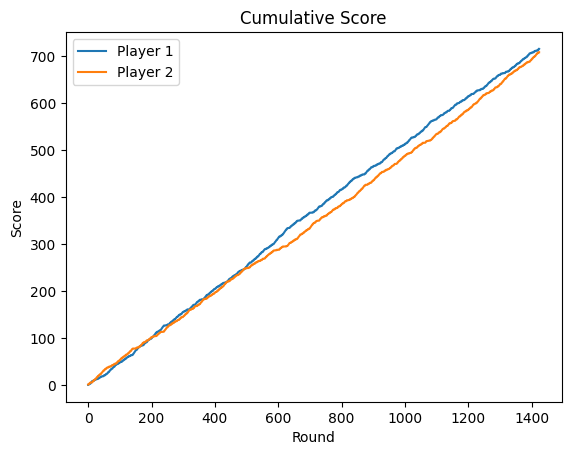

In [6]:
# pick one game to visualize
p1_hist = np.array(h1)[:, 0]
p2_hist = np.array(h2)[:, 0]

plt.figure()
plt.plot(p1_hist, label="Player 1")
plt.plot(p2_hist, label="Player 2")
plt.legend()
plt.xlabel("Round")
plt.ylabel("Score")
plt.title("Cumulative Score")
plt.show()

Probability Player 1 Wins

In [7]:
winners, *_ = simulate_games(1000)

prob_p1 = np.mean(winners == 1)
print("P(Player 1 wins):", prob_p1)

P(Player 1 wins): 0.472


Distribution Check

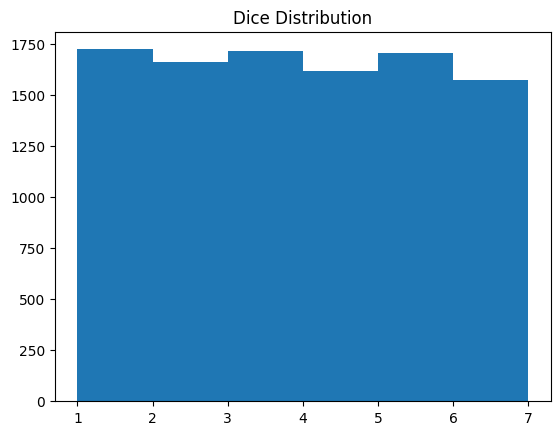

In [8]:
all_rolls = np.random.randint(1, 7, size=10000)

plt.hist(all_rolls, bins=np.arange(1, 8))
plt.title("Dice Distribution")
plt.show()

Shapiro (should FAIL normality)

In [9]:
stat, p = shapiro(all_rolls[:500])
print("Shapiro p-value:", p)

Shapiro p-value: 2.843838523500705e-17


Chi-square (should PASS uniform)

In [10]:
counts = np.bincount(all_rolls)[1:]
expected = [len(all_rolls)/6]*6

chi, p = chisquare(counts, expected)
print("Chi-square p-value:", p)

Chi-square p-value: 0.04859846830997506
